In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType
)

In [2]:
# -----------------------------------
# 1. Creating Spark session
# -----------------------------------
spark = (
    SparkSession.builder
    .appName("OnlineRetailCustomerSegmentation")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/15 19:09:26 WARN Utils: Your hostname, DESKTOP-0H3R790, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/15 19:09:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/15 19:09:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:

# Defining explicit schema

schema = StructType([
    StructField("Invoice", StringType(), True),
    StructField("StockCode", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Quantity", IntegerType(), True),
    StructField("InvoiceDate", StringType(), True),
    StructField("Price", DoubleType(), True),
    StructField("Customer ID", StringType(), True),
    StructField("Country", StringType(), True)
])

In [6]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 347.1 kB/s eta 0:00:0000:0100:01


In [7]:
pip install openpyxl pandas pyspark

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Loading datasets
import pandas as pd

df_2009_2010_pd = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

df_2010_2011_pd = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)


In [9]:

# Combining the two sheets

df_combined_pd = pd.concat(
    [df_2009_2010_pd, df_2010_2011_pd],
    ignore_index=True
)

# Converting pandas DataFrame to Spark DataFrame

df = spark.createDataFrame(df_combined_pd, schema=schema)

df.printSchema()
df.show(5)

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Country: string (nullable = true)



[Stage 0:>                                                          (0 + 1) / 1]

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|RECORD FRAME 7" S...|      48|2009-12-01 07:45:00|  2.1|    13085.0|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|2009-12-01 07:45:00| 1.25|    13085.0|United Kingdom|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
only showing top 5 rows


Traceback (most recent call last):
  File "/home/kokello/Big_Data_Analytics_2026/venv/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kokello/Big_Data_Analytics_2026/venv/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
                                                                                

In [14]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("OnlineRetailCustomerSegmentation") \
    .master("local[2]") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [15]:
df.printSchema()
df.show(5, truncate=False)

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Country: string (nullable = true)

+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12      |2009-12-01 07:45:00|6.95 |13085.0    |United Kingdom|
|489434 |79323P   |PINK CHERRY LIGHTS                 |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
|489434 |79323W   | WHITE CHERRY LIGHTS               |12      |2009-12-01 07:

Traceback (most recent call last):
  File "/home/kokello/Big_Data_Analytics_2026/venv/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kokello/Big_Data_Analytics_2026/venv/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [17]:
#Data Cleaning

from pyspark.sql.functions import col, to_timestamp, regexp_replace, trim, lower

# Standardizing some column names because spaces in names create problems
df = df.withColumnRenamed("Customer ID", "CustomerID")

# Converting InvoiceDate from string to timestamp
df = df.withColumn(
    "InvoiceDate",
    to_timestamp(col("InvoiceDate"), "yyyy-MM-dd HH:mm:ss")
)

#Clean CustomerID values like "13085.0" -> "13085"
df = df.withColumn(
    "CustomerID",
    regexp_replace(col("CustomerID").cast("string"), r"\.0$", "")
)

# Triming text columns
df = df.withColumn("Invoice", trim(col("Invoice"))) \
       .withColumn("StockCode", trim(col("StockCode"))) \
       .withColumn("Description", trim(col("Description"))) \
       .withColumn("Country", trim(col("Country")))

#Removing rows with missing CustomerID because the segmentation is focused on the customer
df = df.filter(
    col("CustomerID").isNotNull() &
    (trim(col("CustomerID")) != "") &
    (~lower(trim(col("CustomerID"))).isin("nan", "null"))
)

#Removing duplicates
df = df.dropDuplicates()

# Remove invalid rows keeping only positive quantity and positive price
df = df.filter((col("Quantity") > 0) & (col("Price") > 0))

# removing cancelled invoices starting with "C"
df = df.filter(~col("Invoice").startswith("C"))

#Creating transaction value
df = df.withColumn("TotalPrice", col("Quantity") * col("Price"))

df.printSchema()
df.show(5, truncate=False)

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- TotalPrice: double (nullable = true)



[Stage 6:==============>                                           (3 + 9) / 12]

+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+------------------+
|Invoice|StockCode|Description                      |Quantity|InvoiceDate        |Price|CustomerID|Country       |TotalPrice        |
+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+------------------+
|489450 |22090    |PAPER BUNTING RETRO SPOTS        |12      |2009-12-01 10:36:00|2.95 |16321     |Australia     |35.400000000000006|
|489522 |22077    |6 RIBBONS RUSTIC CHARM           |1       |2009-12-01 11:45:00|1.65 |15998     |United Kingdom|1.65              |
|489531 |21582    |KINGS CHOICE SMALL TUBE MATCHES  |8       |2009-12-01 11:57:00|1.65 |14871     |United Kingdom|13.2              |
|489536 |21791    |VINTAGE HEADS AND TAILS CARD GAME|1       |2009-12-01 12:13:00|1.25 |16393     |United Kingdom|1.25              |
|489536 |21122    |SET/10 PINK SPOTTY PARTY CANDLES |1       |

In [18]:
from pyspark.sql.functions import max

reference_date = df.select(max("InvoiceDate")).collect()[0][0]

In [19]:
from pyspark.sql.functions import countDistinct, sum, max, datediff

# converting transaction level data into customer level behavioural features

customer_features = df.groupBy("CustomerID").agg(

    # Frequency
    countDistinct("Invoice").alias("Frequency"),

    # Monetary value
    sum("TotalPrice").alias("Monetary"),

    # Quantity behaviour
    sum("Quantity").alias("TotalQuantity"),

    # Recency
    datediff(
        max("InvoiceDate"),
        max("InvoiceDate")
    )
)

In [20]:
from pyspark.sql.functions import lit

customer_features = df.groupBy("CustomerID").agg(

    countDistinct("Invoice").alias("Frequency"),

    sum("TotalPrice").alias("Monetary"),

    sum("Quantity").alias("TotalQuantity"),

    datediff(
        lit(reference_date),
        max("InvoiceDate")
    ).alias("Recency")

)

In [21]:
from pyspark.ml.feature import VectorAssembler

#Assembling features into vector form

assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary", "TotalQuantity"],
    outputCol="features"
)

rfm_data = assembler.transform(customer_features)

In [22]:
#Standardizing

from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(rfm_data)

rfm_scaled = scaler_model.transform(rfm_data)


In [23]:
df.printSchema()
df.show(5, truncate=False)

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- TotalPrice: double (nullable = true)



[Stage 27:====>                                                   (1 + 11) / 12]

+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+------------------+
|Invoice|StockCode|Description                      |Quantity|InvoiceDate        |Price|CustomerID|Country       |TotalPrice        |
+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+------------------+
|489450 |22090    |PAPER BUNTING RETRO SPOTS        |12      |2009-12-01 10:36:00|2.95 |16321     |Australia     |35.400000000000006|
|489522 |22077    |6 RIBBONS RUSTIC CHARM           |1       |2009-12-01 11:45:00|1.65 |15998     |United Kingdom|1.65              |
|489531 |21582    |KINGS CHOICE SMALL TUBE MATCHES  |8       |2009-12-01 11:57:00|1.65 |14871     |United Kingdom|13.2              |
|489536 |21791    |VINTAGE HEADS AND TAILS CARD GAME|1       |2009-12-01 12:13:00|1.25 |16393     |United Kingdom|1.25              |
|489536 |21122    |SET/10 PINK SPOTTY PARTY CANDLES |1       |

In [24]:
customer_features.printSchema()
customer_features.show(5, truncate=False)

root
 |-- CustomerID: string (nullable = true)
 |-- Frequency: long (nullable = false)
 |-- Monetary: double (nullable = true)
 |-- TotalQuantity: long (nullable = true)
 |-- Recency: integer (nullable = true)



[Stage 32:=====================>                                   (5 + 8) / 13]

+----------+---------+-----------------+-------------+-------+
|CustomerID|Frequency|Monetary         |TotalQuantity|Recency|
+----------+---------+-----------------+-------------+-------+
|12847     |2        |1609.0           |1497         |22     |
|13610     |14       |2103.71          |869          |12     |
|15555     |36       |11243.91         |8511         |12     |
|15574     |6        |1101.44          |750          |177    |
|15634     |2        |554.6500000000001|227          |17     |
+----------+---------+-----------------+-------------+-------+
only showing top 5 rows


In [25]:
rfm_data.printSchema()
rfm_data.show(5, truncate=False)

root
 |-- CustomerID: string (nullable = true)
 |-- Frequency: long (nullable = false)
 |-- Monetary: double (nullable = true)
 |-- TotalQuantity: long (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- features: vector (nullable = true)



[Stage 42:==========================>                              (6 + 7) / 13]

+----------+---------+-----------------+-------------+-------+----------------------------------+
|CustomerID|Frequency|Monetary         |TotalQuantity|Recency|features                          |
+----------+---------+-----------------+-------------+-------+----------------------------------+
|12847     |2        |1609.0           |1497         |22     |[22.0,2.0,1609.0,1497.0]          |
|13610     |14       |2103.71          |869          |12     |[12.0,14.0,2103.71,869.0]         |
|15555     |36       |11243.91         |8511         |12     |[12.0,36.0,11243.91,8511.0]       |
|15574     |6        |1101.44          |750          |177    |[177.0,6.0,1101.44,750.0]         |
|15634     |2        |554.6500000000001|227          |17     |[17.0,2.0,554.6500000000001,227.0]|
+----------+---------+-----------------+-------------+-------+----------------------------------+
only showing top 5 rows


In [26]:
rfm_scaled.select(
    "CustomerID", "Recency", "Frequency", "Monetary", "TotalQuantity", "scaled_features"
).show(5, truncate=False)

[Stage 52:==========================>                              (6 + 7) / 13]

+----------+-------+---------+-----------------+-------------+-------------------------------------------------------------------------------------+
|CustomerID|Recency|Frequency|Monetary         |TotalQuantity|scaled_features                                                                      |
+----------+-------+---------+-----------------+-------------+-------------------------------------------------------------------------------------+
|12847     |22     |2        |1609.0           |1497         |[-0.8543750051889025,-0.32971406865699643,-0.09327039917096414,-0.032862292487199074]|
|13610     |12     |14       |2103.71          |869          |[-0.9021409989979893,0.592695463996396,-0.05901272681017575,-0.10361251480941884]    |
|15555     |12     |36       |11243.91         |8511         |[-0.9021409989979893,2.2837796071942824,0.5739277371223868,0.7573320695638351]       |
|15574     |177    |6        |1101.44          |750          |[-0.11400210114805741,-0.02224422443919893,-

In [27]:
from pyspark.ml.clustering import KMeans

In [28]:
#Training K-means model

kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=4,
    seed=42
)

model = kmeans.fit(rfm_scaled)

In [29]:
#Generating cluster assignments

cluster_results = model.transform(rfm_scaled)

cluster_results.select(
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "cluster"
).show(10, truncate=False)

[Stage 233:==============================================>        (11 + 2) / 13]

+----------+-------+---------+-----------------+-------------+-------+
|CustomerID|Recency|Frequency|Monetary         |TotalQuantity|cluster|
+----------+-------+---------+-----------------+-------------+-------+
|12847     |22     |2        |1609.0           |1497         |1      |
|13610     |12     |14       |2103.71          |869          |1      |
|15555     |12     |36       |11243.91         |8511         |1      |
|15574     |177    |6        |1101.44          |750          |1      |
|15634     |17     |2        |554.6500000000001|227          |1      |
|13192     |95     |6        |2558.58          |1629         |1      |
|14157     |19     |5        |978.69           |521          |1      |
|15271     |7      |24       |4528.54          |2412         |1      |
|17686     |7      |9        |8296.81          |3583         |1      |
|13865     |58     |4        |501.56           |204          |1      |
+----------+-------+---------+-----------------+-------------+-------+
only s

In [31]:
# Finding otimal number of clusters

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    predictionCol="cluster",
    featuresCol="scaled_features",
    metricName="silhouette"
)

silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(
        featuresCol="scaled_features",
        predictionCol="cluster",
        k=k,
        seed=42
    )

    model = kmeans.fit(rfm_scaled)
    predictions = model.transform(rfm_scaled)
    score = evaluator.evaluate(predictions)

    silhouette_scores[k] = score

print(silhouette_scores)

[Stage 1231:======================>                                (5 + 7) / 12]

{2: 0.9900675436058394, 3: 0.9455032407674439, 4: 0.6956711961191295, 5: 0.5264461532686456, 6: 0.7037852884561548}


In [32]:
# Inspecting clusters

final_kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=2,
    seed=42
)

final_model = final_kmeans.fit(rfm_scaled)
final_clusters = final_model.transform(rfm_scaled)

final_clusters.groupBy("cluster").avg(
    "Recency", "Frequency", "Monetary", "TotalQuantity"
).show()

[Stage 1368:>                                                     (0 + 12) / 13]

+-------+------------------+-----------------+------------------+------------------+
|cluster|      avg(Recency)|   avg(Frequency)|     avg(Monetary)|avg(TotalQuantity)|
+-------+------------------+-----------------+------------------+------------------+
|      1| 35.27272727272727|130.0909090909091|175181.87318181817|109814.09090909091|
|      0|201.48890027322403|5.824282786885246| 2308.880303620222|1382.8623633879781|
+-------+------------------+-----------------+------------------+------------------+



In [33]:
#checking cluster sizes

final_clusters.groupBy("cluster").count().show()

[Stage 1383:============>                                         (3 + 10) / 13]

+-------+-----+
|cluster|count|
+-------+-----+
|      1|   22|
|      0| 5856|
+-------+-----+



In [34]:
#Final Model

kmeans_final = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=2,
    seed=42
)

final_model = kmeans_final.fit(rfm_scaled)

final_clusters = final_model.transform(rfm_scaled)

In [35]:
#Inspecting cluster x-tics

final_clusters.groupBy("cluster").avg(
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity"
).show()

[Stage 1518:========>                                             (2 + 11) / 13]

+-------+------------------+-----------------+------------------+------------------+
|cluster|      avg(Recency)|   avg(Frequency)|     avg(Monetary)|avg(TotalQuantity)|
+-------+------------------+-----------------+------------------+------------------+
|      1| 35.27272727272727|130.0909090909091|175181.87318181817|109814.09090909091|
|      0|201.48890027322403|5.824282786885246| 2308.880303620222|1382.8623633879781|
+-------+------------------+-----------------+------------------+------------------+



In [36]:
#Evaluating model

from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    predictionCol="cluster",
    featuresCol="scaled_features",
    metricName="silhouette"
)

silhouette = evaluator.evaluate(final_clusters)

print("Silhouette Score:", silhouette)

[Stage 1544:=================================>                     (8 + 5) / 13]

Silhouette Score: 0.9900675436058394


In [37]:
#Generating structured dataset
final_predictions = model.transform(rfm_scaled)

# selecting useful columns
customer_clusters = final_predictions.select(
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "cluster"
)

customer_clusters.show(10)

[Stage 1559:>                                                     (0 + 12) / 13]

+----------+-------+---------+-----------------+-------------+-------+
|CustomerID|Recency|Frequency|         Monetary|TotalQuantity|cluster|
+----------+-------+---------+-----------------+-------------+-------+
|     12847|     22|        2|           1609.0|         1497|      3|
|     13610|     12|       14|          2103.71|          869|      3|
|     15555|     12|       36|         11243.91|         8511|      1|
|     15574|    177|        6|          1101.44|          750|      3|
|     15634|     17|        2|554.6500000000001|          227|      3|
|     13192|     95|        6|          2558.58|         1629|      3|
|     14157|     19|        5|           978.69|          521|      3|
|     15271|      7|       24|          4528.54|         2412|      1|
|     17686|      7|        9|          8296.81|         3583|      3|
|     13865|     58|        4|           501.56|          204|      3|
+----------+-------+---------+-----------------+-------------+-------+
only s

In [38]:
model.getK()

6

In [39]:
#Retraining with k=2

kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=2,
    seed=42
)

model = kmeans.fit(rfm_scaled)

final_predictions = model.transform(rfm_scaled)

In [40]:
final_predictions.select("cluster").distinct().show()

[Stage 1689:=================================================>    (12 + 1) / 13]

+-------+
|cluster|
+-------+
|      1|
|      0|
+-------+



In [41]:
#Generating the structured dataset

customer_clusters = final_predictions.select(
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "cluster"
)

customer_clusters.show()

[Stage 1704:============>                                         (3 + 10) / 13]

+----------+-------+---------+------------------+-------------+-------+
|CustomerID|Recency|Frequency|          Monetary|TotalQuantity|cluster|
+----------+-------+---------+------------------+-------------+-------+
|     12847|     22|        2|            1609.0|         1497|      0|
|     13610|     12|       14|           2103.71|          869|      0|
|     15555|     12|       36|          11243.91|         8511|      0|
|     15574|    177|        6|           1101.44|          750|      0|
|     15634|     17|        2| 554.6500000000001|          227|      0|
|     13192|     95|        6|           2558.58|         1629|      0|
|     14157|     19|        5|            978.69|          521|      0|
|     15271|      7|       24|           4528.54|         2412|      0|
|     17686|      7|        9|           8296.81|         3583|      0|
|     13865|     58|        4|            501.56|          204|      0|
|     17757|      1|       56| 9074.050000000001|         5011| 

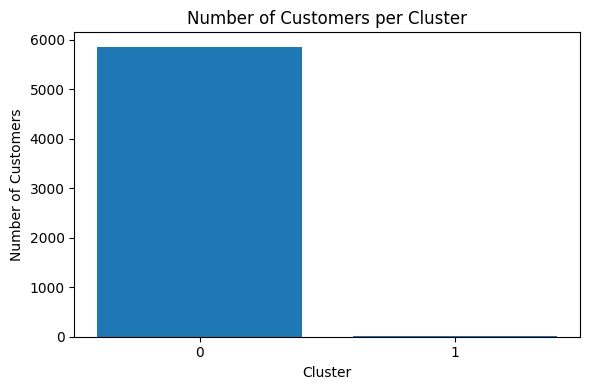

In [42]:
import matplotlib.pyplot as plt

# Count customers per cluster
cluster_counts = (
    final_predictions.groupBy("cluster")
    .count()
    .orderBy("cluster")
    .toPandas()
)

plt.figure(figsize=(6, 4))
plt.bar(cluster_counts["cluster"].astype(str), cluster_counts["count"])
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers per Cluster")
plt.tight_layout()
plt.show()

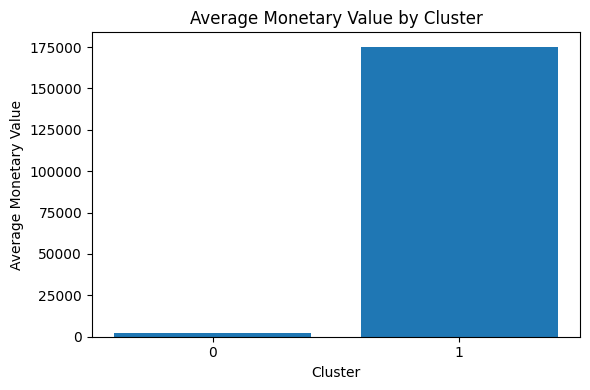

In [43]:
from pyspark.sql import functions as F

# Average monetary value per cluster
avg_monetary = (
    final_predictions.groupBy("cluster")
    .agg(F.avg("Monetary").alias("avg_monetary"))
    .orderBy("cluster")
    .toPandas()
)

plt.figure(figsize=(6, 4))
plt.bar(avg_monetary["cluster"].astype(str), avg_monetary["avg_monetary"])
plt.xlabel("Cluster")
plt.ylabel("Average Monetary Value")
plt.title("Average Monetary Value by Cluster")
plt.tight_layout()
plt.show()

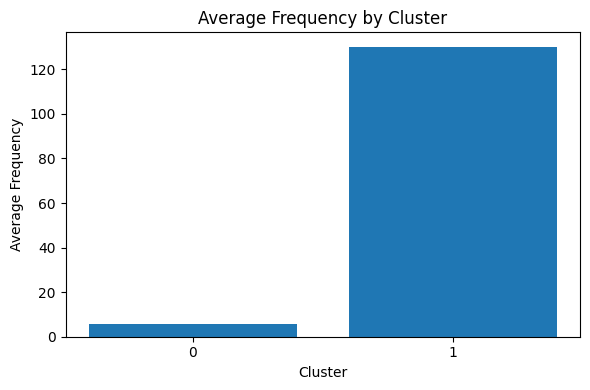

In [44]:
# Average frequency per cluster
avg_frequency = (
    final_predictions.groupBy("cluster")
    .agg(F.avg("Frequency").alias("avg_frequency"))
    .orderBy("cluster")
    .toPandas()
)

plt.figure(figsize=(6, 4))
plt.bar(avg_frequency["cluster"].astype(str), avg_frequency["avg_frequency"])
plt.xlabel("Cluster")
plt.ylabel("Average Frequency")
plt.title("Average Frequency by Cluster")
plt.tight_layout()
plt.show()

In [45]:
#saving structured dataset as CSV

customer_clusters.toPandas().to_csv("customer_segments.csv", index=False)

In [46]:
#Generating cluster report

cluster_summary = final_predictions.groupBy("cluster").agg(
    F.count("*").alias("Customers"),
    F.avg("Recency").alias("Avg_Recency"),
    F.avg("Frequency").alias("Avg_Frequency"),
    F.avg("Monetary").alias("Avg_Monetary"),
    F.avg("TotalQuantity").alias("Avg_TotalQuantity")
)

cluster_summary.show()

[Stage 1802:============>                                         (3 + 10) / 13]

+-------+---------+------------------+-----------------+------------------+------------------+
|cluster|Customers|       Avg_Recency|    Avg_Frequency|      Avg_Monetary| Avg_TotalQuantity|
+-------+---------+------------------+-----------------+------------------+------------------+
|      1|       22| 35.27272727272727|130.0909090909091|175181.87318181817|109814.09090909091|
|      0|     5856|201.48890027322403|5.824282786885246| 2308.880303620222|1382.8623633879781|
+-------+---------+------------------+-----------------+------------------+------------------+



In [47]:
#Saving report table

cluster_summary.toPandas().to_csv("cluster_summary_report.csv", index=False)

In [48]:
#Saving trained model

model.save("kmeans_customer_segmentation_model")